# Метод распространения меток на основе случайных блужданий (RW-LPA)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Лекция 5: Случайные блуждания на графах"
* Документация:
    * https://networkx.org/documentation/stable/reference/generated/networkx.linalg.graphmatrix.adjacency_matrix.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_power.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html

## Вопросы для совместного обсуждения

1\. Обсудите принцип работы алгоритма RW-LPA, принцип построения блочной матрицы $\mathbf{P}$ и матрицы начального состояния меток $\mathbf{Y_0}$.

$$\mathbf{P} = \begin{pmatrix}
\mathbf{P}_{ll}& \mathbf{P}_{lu}\\
\mathbf{P}_{ul}& \mathbf{P}_{uu}\\
\end{pmatrix} = \begin{pmatrix}
\mathbf{I}& \mathbf{0}\\
\mathbf{P}_{ul}& \mathbf{P}_{uu}\\
\end{pmatrix}$$

$$\mathbf{Y_0} = \begin{pmatrix}
\mathbf{Y_{l}}\\
\mathbf{Y_{u}}\\
\end{pmatrix}= \begin{pmatrix}
\mathbf{Y_{l}}\\
\mathbf{0}\\
\end{pmatrix}$$

## Задачи для самостоятельного решения

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

<p class="task" id="1"></p>

1\. Загрузите граф Karate Club. Получите значения атрибута `club`, хранящегося на узлах. Выберите случайным образом 4 узла, относящихся к клубу `Mr. Hi` и 4 узла, относящихся к клубу `Officer`. Получите матрицу смежности, в которой узлы перенумерованы  таким образом, чтобы строки и столбцы с номерами 0, 1, ... 7 принадлежали узлам, которые были выбраны на предыдущем шаге. 

- [ ] Проверено на семинаре

In [2]:
g = nx.karate_club_graph()
cl = nx.get_node_attributes(g, 'club')

mh =[n for n, c in cl.items() if c == 'Mr. Hi']
of =[n for n, c in cl.items() if c == 'Officer']

s_mh = random.sample(mh, 4)
s_of = random.sample(of, 4)

lb = s_mh + s_of
ulb =[n for n in g.nodes if n not in lb]

no = lb + ulb
a = nx.to_numpy_array(g, nodelist=no)

<p class="task" id="2"></p>

2\. Получите блочную матрицу $\mathbf{P}$ и матрицу начального состояния меток $\mathbf{Y_0} \in \{0,1\}^{N\times2}$
$$\mathbf{P} = \begin{pmatrix}
\mathbf{P}_{ll}& \mathbf{P}_{lu}\\
\mathbf{P}_{ul}& \mathbf{P}_{uu}\\
\end{pmatrix} = \begin{pmatrix}
\mathbf{I}& \mathbf{0}\\
\mathbf{P}_{ul}& \mathbf{P}_{uu}\\
\end{pmatrix}$$

$$\mathbf{Y_0} = \begin{pmatrix}
\mathbf{Y_{l}}\\
\mathbf{Y_{u}}\\
\end{pmatrix}= \begin{pmatrix}
\mathbf{Y_{l}}\\
\mathbf{0}\\
\end{pmatrix}$$

Выведите на экран след матрицы $\mathbf{P}$. Выведите на экран количество ненулевых элементов матрицы $\mathbf{Y_0}$

- [ ] Проверено на семинаре

In [3]:
n = len(no)
l = len(lb)

d = a.sum(axis=1)
pt = np.diag(1 / d) @ a

P = np.zeros((n, n))
P[:l, :l] = np.eye(l)
P[l:, :] = pt[l:, :]

Y0 = np.zeros((n, 2))
Y0[:4, 0] = 1
Y0[4:l, 1] = 1

print(np.trace(P))
print(np.count_nonzero(Y0))

8.0
8


<p class="task" id="3"></p>

3\. Известно, что для блочной матрицы справедливо:

$$\mathbf{P}^{\infty} = 
\begin{pmatrix}
\mathbf{I}& \mathbf{0}\\
(\mathbf{I}-\mathbf{P}_{uu})^{-1}\mathbf{P}_{ul}& \mathbf{0}\\
\end{pmatrix}$$

Получите оценку $\mathbf{P}^{\infty}$ путем возведения матрицы в достаточно большую степень. Свяжите блоки матрицы с отдельными переменными `P_ll`, `P_lu`, `P_ul`, `P_uu` и продемонстрируйте, что каждый блок полученной матрицы удовлетворяет формуле выше при помощи функции `np.allclose`.

- [ ] Проверено на семинаре

In [4]:
pi = np.linalg.matrix_power(P, 1000)

P_ll = pi[:l, :l]
P_lu = pi[:l, l:]
P_ul = pi[l:, :l]
P_uu = pi[l:, l:]

puuo = P[l:, l:]
pulo = P[l:, :l]

e_ul = np.linalg.inv(np.eye(n - l) - puuo) @ pulo

print(np.allclose(P_ll, np.eye(l)))
print(np.allclose(P_lu, np.zeros((l, n - l))))
print(np.allclose(P_ul, e_ul))
print(np.allclose(P_uu, np.zeros((n - l, n - l))))

True
True
True
True


<p class="task" id="4"></p>

4\. Используя Базовый вариант RW-LPA , расставьте метки для всех узлов. Визуализируйте сеть, показав цветом контура вокруг узла принадлежность узла к одному из сообществ, а цветом цветом заливки узла - сообщество, к которому узел был отнесен алгоритмом.

![](https://i.imgur.com/R4ZbGEV.png)

- [ ] Проверено на семинаре

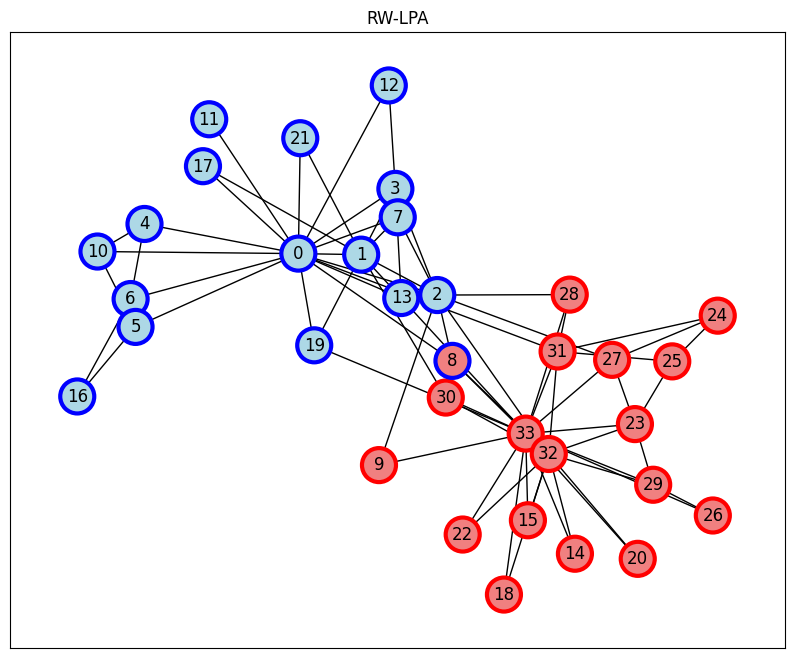

In [5]:
y = pi @ Y0
pl = np.argmax(y, axis=1)

tl = [0 if cl[nd] == 'Mr. Hi' else 1 for nd in no]

pc =['lightblue' if x == 0 else 'lightcoral' for x in pl]
tc =['blue' if x == 0 else 'red' for x in tl]

f, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(g)

nx.draw_networkx_edges(g, pos, ax=ax)
nx.draw_networkx_nodes(g, pos, nodelist=no, node_color=pc, edgecolors=tc, linewidths=3, node_size=600, ax=ax)
nx.draw_networkx_labels(g, pos, ax=ax)

ax.set_title("RW-LPA")
plt.show()